In [ ]:
# obesity prediction using logistic regression

In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\onc\Downloads\Obesity Classification.csv")
df

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese
...,...,...,...,...,...,...
103,11,Male,3.9,175,10,Underweight
104,16,Female,3.9,160,10,Underweight
105,21,Male,5.6,180,15,Underweight
106,26,Female,5.6,150,15,Underweight


In [2]:
df.shape

(108, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     108 non-null    int64  
 1   Gender  108 non-null    object 
 2   BMI     108 non-null    float64
 3   Height  108 non-null    int64  
 4   Weight  108 non-null    int64  
 5   Label   108 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.2+ KB


In [7]:
df.describe()

,Age,BMI,Height,Weight
count,108.000000,108.000000,108.000000,108.000000
mean,46.555556,20.549074,166.574074,59.490741
std,24.720620,7.583818,27.873615,28.856233
min,11.000000,3.900000,120.000000,10.000000
25%,27.000000,16.700000,140.000000,35.000000
50%,42.500000,21.200000,175.000000,55.000000
75%,59.250000,26.100000,190.000000,85.000000
max,112.000000,37.200000,210.000000,120.000000


In [8]:
df.describe(include='object')

,Gender,Label
count,108,108
unique,2,4
top,Male,Underweight
freq,56,47


In [9]:
df.isnull().sum()

Age       0
Gender    0
BMI       0
Height    0
Weight    0
Label     0
dtype: int64

In [10]:
print(df.duplicated().sum())

0


In [ ]:
# EDA

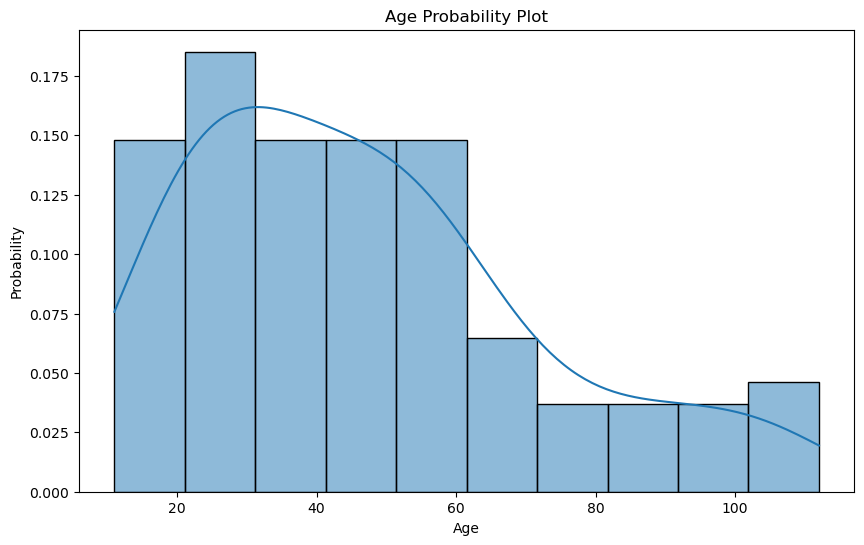

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=10, stat='probability')
plt.xlabel('Age')
plt.ylabel('Probability')
plt.title('Age Probability Plot')
plt.show()

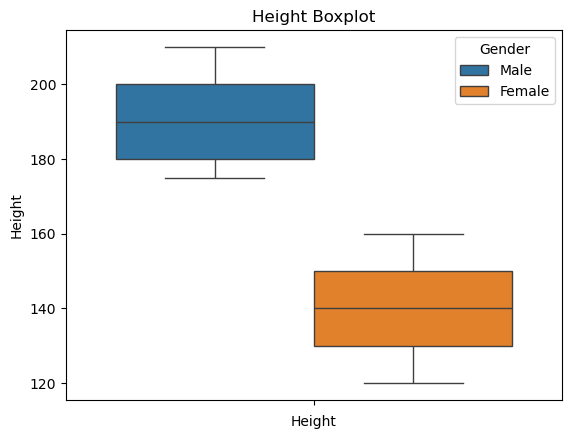

In [12]:
sns.boxplot(y='Height', data=df, hue='Gender')
plt.xlabel('Height')
plt.title('Height Boxplot')
plt.show()

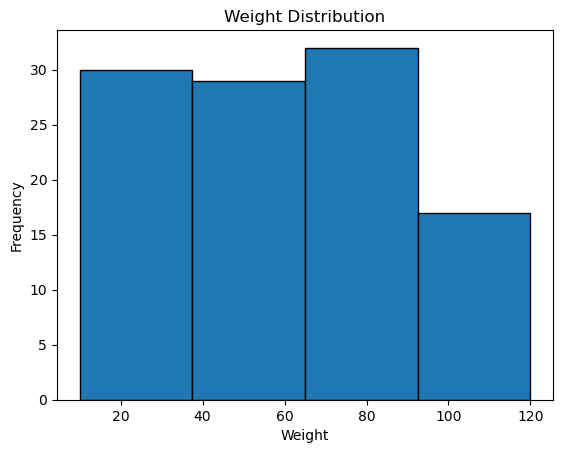

In [13]:
df['Weight'].plot(kind='hist', bins=4, edgecolor='black')
plt.xlabel('Weight')
plt.title('Weight Distribution')
plt.show()

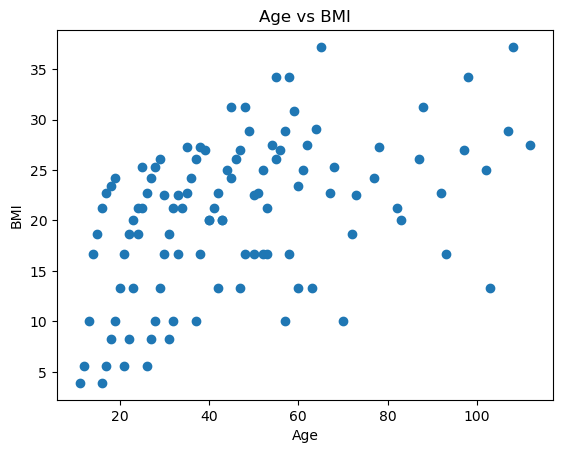

In [14]:
plt.scatter(df['Age'], df['BMI'])
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI')
plt.show()

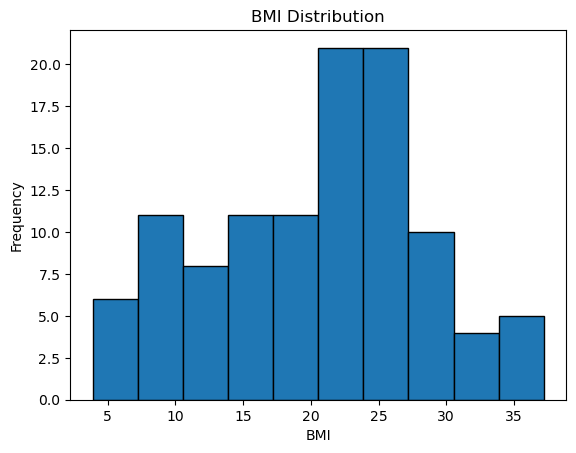

In [15]:
df['BMI'].plot(kind='hist', bins=10, edgecolor='black')
plt.xlabel('BMI')
plt.title('BMI Distribution')
plt.show()

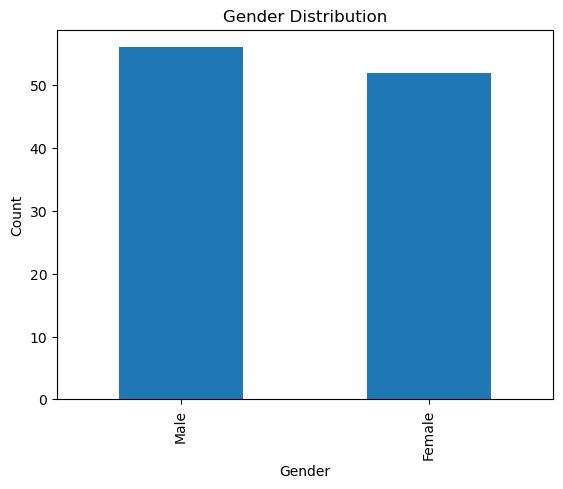

In [16]:
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

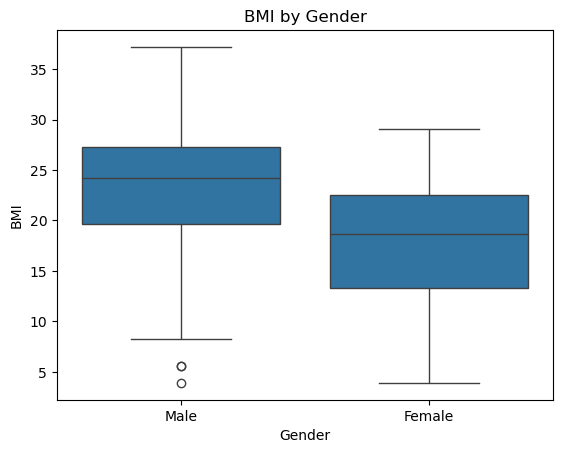

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Gender', y='BMI')

plt.title('BMI by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.show()

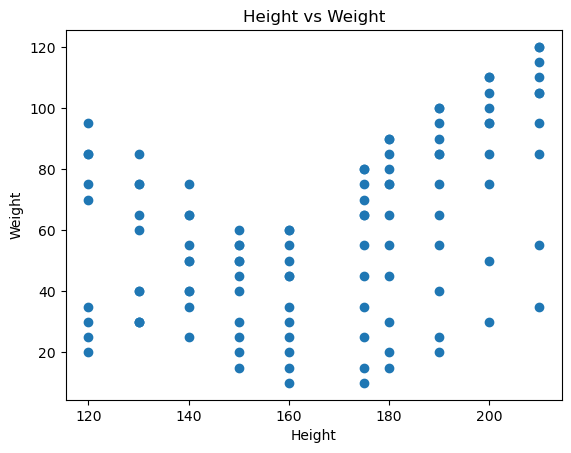

In [18]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

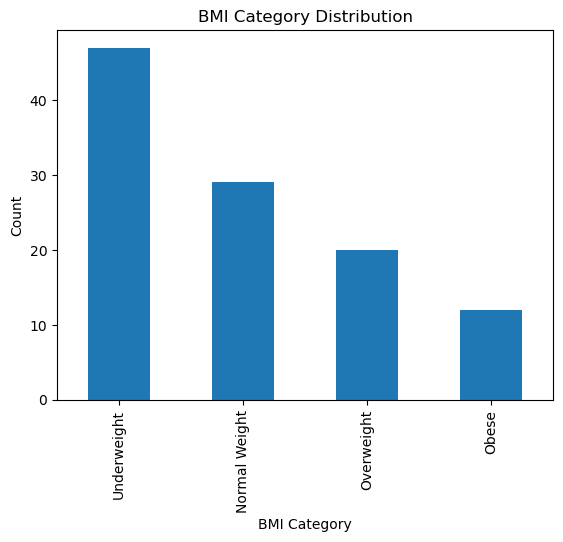

In [19]:
df['Label'].value_counts().plot(kind='bar')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.title('BMI Category Distribution')
plt.show()

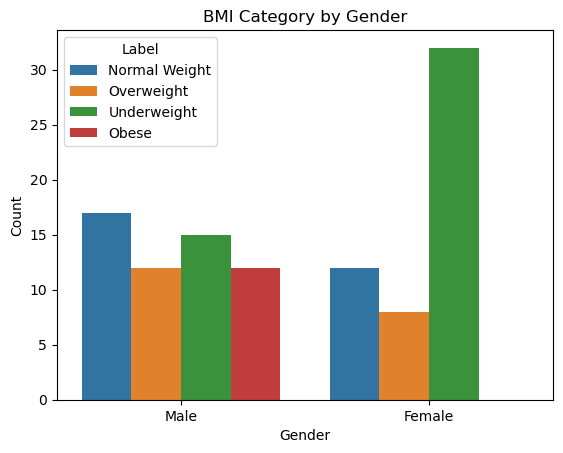

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Gender', hue='Label')

plt.title('BMI Category by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [21]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


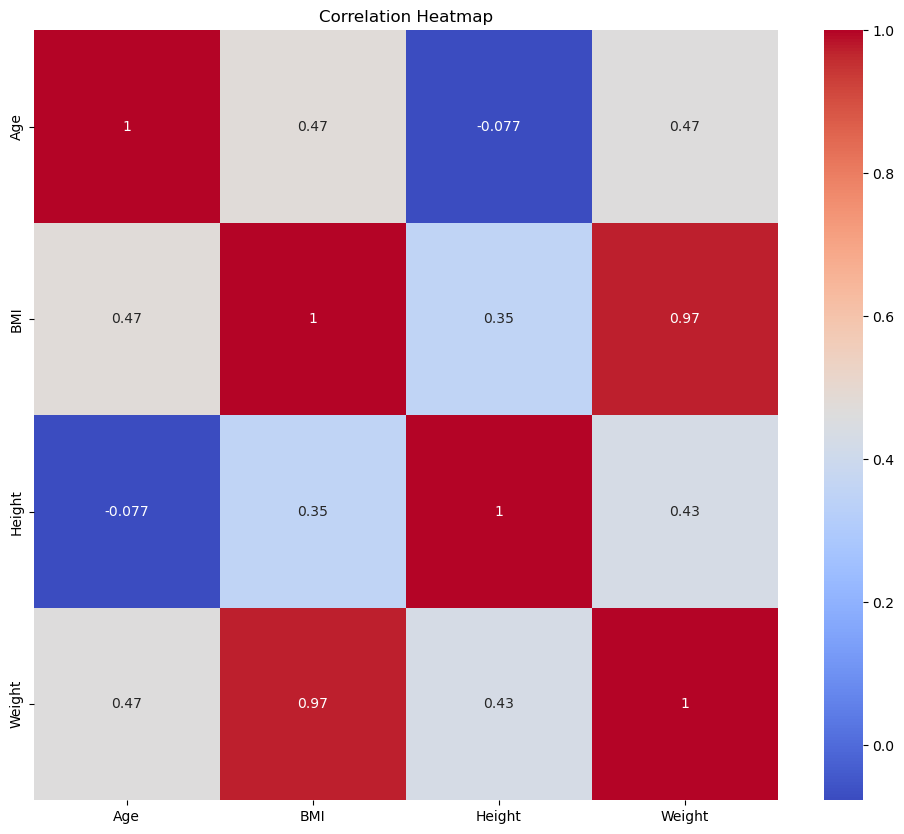

In [22]:
plt.figure(figsize=(12, 10))
num_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
target_col = "Label"  
corr_matrix = num_df.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.9:
            columns_to_drop.append(corr_matrix.columns[i])

print(columns_to_drop)

['Weight']


In [24]:
# df.drop("Weight", axis=1, inplace=True) # i dont deop it as i have less features for training the model

In [25]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


In [26]:
# Splitting the data for training

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 1)

In [27]:
df_train.head()

,Age,Gender,BMI,Height,Weight,Label
32,39,Male,27.0,190,95,Overweight
73,40,Female,20.0,140,50,Underweight
19,63,Female,13.3,120,30,Underweight
27,103,Female,13.3,130,30,Underweight
36,59,Male,30.8,210,115,Obese


In [28]:
df_test.head()

,Age,Gender,BMI,Height,Weight,Label
100,47,Female,13.3,130,30,Underweight
90,48,Female,16.7,130,40,Underweight
92,58,Female,16.7,120,35,Underweight
89,43,Male,20.0,200,50,Underweight
101,52,Male,16.7,210,35,Underweight


In [29]:
print("the shape of the train data set is : ", df_train.shape)
print("the shape of the test data set is : ", df_test.shape)

the shape of the train data set is :  (75, 6)
the shape of the test data set is :  (33, 6)


In [30]:
df_train.head()

,Age,Gender,BMI,Height,Weight,Label
32,39,Male,27.0,190,95,Overweight
73,40,Female,20.0,140,50,Underweight
19,63,Female,13.3,120,30,Underweight
27,103,Female,13.3,130,30,Underweight
36,59,Male,30.8,210,115,Obese


In [ ]:
# Feature Encoding


In [31]:
nominal_cols = ['Gender']
label_col = ['Label']

In [32]:
df_train['Gender'] = (df_train['Gender'] == 'Male').astype(int)
df_test['Gender'] = (df_test['Gender'] == 'Male').astype(int)

In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_train['Label'] = le.fit_transform(df_train['Label'])
df_test['Label'] = le.transform(df_test['Label'])

In [34]:
for i, label in enumerate(le.classes_):
    print(f"{i} -> {label}")

0 -> Normal Weight
1 -> Obese
2 -> Overweight
3 -> Underweight


In [35]:
df.head()

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
1,30,Female,22.5,160,60,Normal Weight
2,35,Male,27.3,180,90,Overweight
3,40,Female,20.0,150,50,Underweight
4,45,Male,31.2,190,100,Obese


In [36]:
# Feature Scaling

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_train[['BMI','Age','Height','Weight']] = scaler.fit_transform(df_train[['BMI','Age','Height','Weight']])
df_test[['BMI','Age','Height','Weight']] = scaler.transform(df_test[['BMI','Age','Height','Weight']])

In [37]:
df_train.head()


,Age,Gender,BMI,Height,Weight,Label
32,0.277228,1,0.693694,0.777778,0.772727,2
73,0.287129,0,0.483483,0.222222,0.363636,3
19,0.514851,0,0.282282,0.000000,0.181818,3
27,0.910891,0,0.282282,0.111111,0.181818,3
36,0.475248,1,0.807808,1.000000,0.954545,1


In [38]:
#Preparing the Input variable and Target Variable

In [39]:
y_train = df_train.pop('Label')
X_train = df_train

In [40]:
y_test = df_test.pop('Label')
X_test = df_test

In [41]:
X_train

,Age,Gender,BMI,Height,Weight
32,0.277228,1,0.693694,0.777778,0.772727
73,0.287129,0,0.483483,0.222222,0.363636
19,0.514851,0,0.282282,0.000000,0.181818
27,0.910891,0,0.282282,0.111111,0.181818
36,0.475248,1,0.807808,1.000000,0.954545
...,...,...,...,...,...
75,0.386139,0,0.558559,0.111111,0.454545
9,0.584158,0,0.183183,0.000000,0.090909
72,0.237624,1,0.564565,0.777778,0.500000
12,0.168317,1,0.642643,0.666667,0.636364


In [42]:
y_train

32    2
73    3
19    3
27    3
36    1
     ..
75    0
9     3
72    0
12    0
37    2
Name: Label, Length: 75, dtype: int64

In [43]:
# # Importing RFE and LogisticRegression
# from sklearn.feature_selection import RFE
# from sklearn.linear_model import LogisticRegression

# # Create model
# model = LogisticRegression()

# # Select top 5 features
# rfe = RFE(estimator=model, n_features_to_select=3)

# # Fit RFE
# X_rfe = rfe.fit_transform(X_train, y_train)

# # Selected feature names
# selected_features = X_train.columns[rfe.support_]

# print("Selected Features:")
# print(list(selected_features))



In [44]:
# feature_ranking = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Selected': rfe.support_,
#     'Rank': rfe.ranking_
# })

# feature_ranking.sort_values('Rank').reset_index(drop=True)

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [46]:
for i in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {i[0]}, Predicted: {i[1]}")

Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 2, Predicted: 2
Actual: 3, Predicted: 3
Actual: 2, Predicted: 1
Actual: 0, Predicted: 0
Actual: 2, Predicted: 1


In [47]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.73


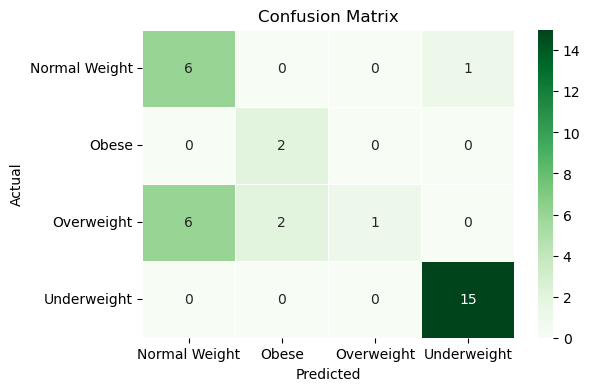

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = le.classes_
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
abels = le.classes_
abels

array(['Normal Weight', 'Obese', 'Overweight', 'Underweight'],
      dtype=object)

In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.50      1.00      0.67         2
           2       1.00      0.11      0.20         9
           3       0.94      1.00      0.97        15

    accuracy                           0.73        33
   macro avg       0.73      0.74      0.62        33
weighted avg       0.84      0.73      0.67        33



In [51]:
import pandas as pd
import gradio as gr

def predict_obesity(age, gender, height, weight, bmi):
    gender_encoded = 1 if gender == "Male" else 0

    # Create input dataframe with same column order as training data
    input_df = pd.DataFrame({
        'Age': [age],
        'Gender': [gender_encoded],
        'Height': [height],
        'Weight': [weight],
        'BMI': [bmi]
    })

    # Reorder columns to match training data
    input_df = input_df[X_train.columns]

    # Scale features using the fitted scaler
    input_df[['BMI', 'Age', 'Height', 'Weight']] = scaler.transform(input_df[['BMI', 'Age', 'Height', 'Weight']])

    # Predict
    prediction = model.predict(input_df)

    # Map back to label name
    label = le.inverse_transform(prediction)[0]
    return f"Predicted Obesity Category: {label}"

gr.Interface(
    fn=predict_obesity,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(choices=["Male", "Female"], label="Gender"),
        gr.Number(label="Height (cm)"),
        gr.Number(label="Weight (kg)"),
        gr.Number(label="BMI"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Obesity Classification",
    flagging_mode="never"
).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


C:\Users\onc\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [52]:
df.head(1)

,Age,Gender,BMI,Height,Weight,Label
0,25,Male,25.3,175,80,Normal Weight
